<a href="https://colab.research.google.com/github/melihaslan233-glitch/Water-Quality-data-/blob/main/waterqualitySAMSUNG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format #displaying float numbers with 2 decimal places

df = pd.read_csv('/content/drive/MyDrive/water_potability.csv')

df.head() # gives us first five rows

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,0
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,0
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,0
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,0
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,0


In [185]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


# Missing Values

In [186]:
df.isnull().sum() # Checking for missing values

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [187]:
# printing missing values
print(f"\nTotal missing: {df.isnull().sum().sum()} values")


Total missing: 1434 values



# missing values while exluding potabilğty

In [188]:
print(df['Potability'].value_counts())

df = df.dropna()

print("After dropping missing values")
print(df['Potability'].value_counts())

Potability
0    1998
1    1278
Name: count, dtype: int64
After dropping missing values
Potability
0    1200
1     811
Name: count, dtype: int64


In [189]:
# Checking missing values
print("Missing values after filling with mean")
print(df.isnull().sum())

Missing values after filling with mean
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


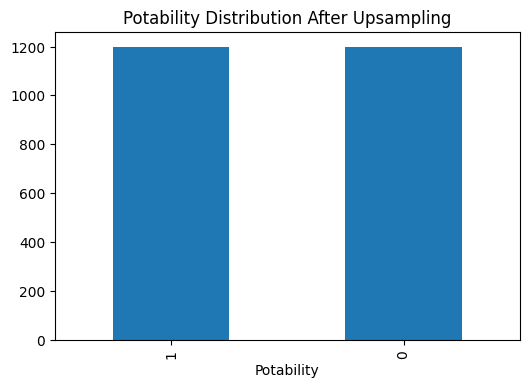

In [190]:
#Fixing class imbalance with upsampling
from sklearn.utils import resample, shuffle

zero = df[df['Potability'] == 0]
one  = df[df['Potability'] == 1]

# Upsample the minority class (potable water) to match majority
df_minority_upsampled = resample(one, replace=True, n_samples=len(zero), random_state=42)
df = pd.concat([zero, df_minority_upsampled])
df = shuffle(df, random_state=42)


plt.figure(figsize=(6, 4))
df['Potability'].value_counts().plot(kind='bar')
plt.title("Potability Distribution After Upsampling")
plt.show()

# Plotting potability

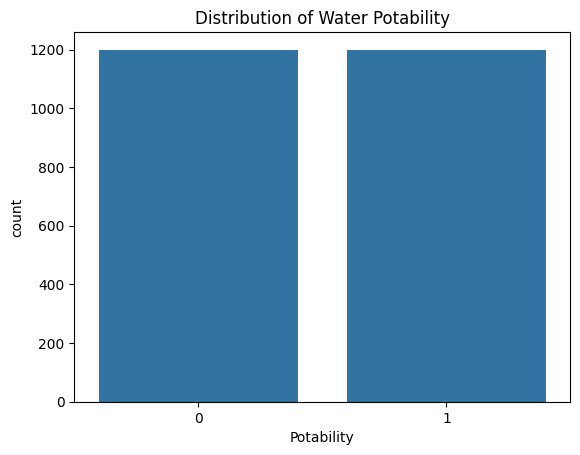

In [191]:
sns.countplot(x='Potability', data=df)
plt.title("Distribution of Water Potability")
plt.show()

# Most of the water is not drinkable

# Correlation Matrix of Potability

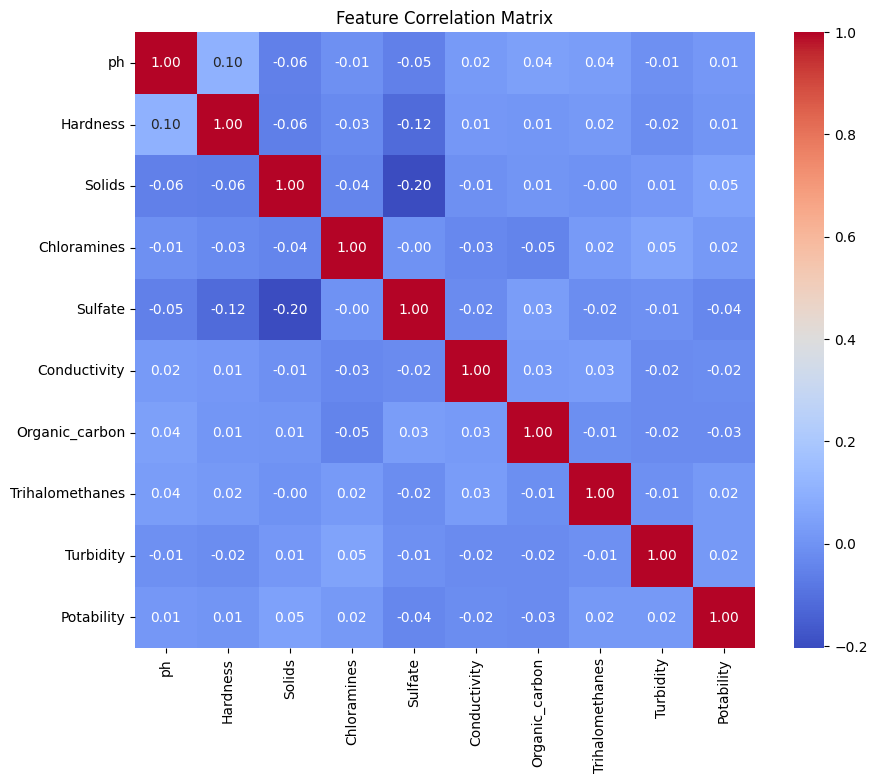

In [192]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,fmt='.2f',cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()
# fmt='.2f' Stops the numbers two decimal places

In [172]:
#modeling before merging data:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

print("original data set before merge")

# Features and target
X_orig = df.drop(columns=['Potability'])
y_orig = df['Potability']

# 90% train, 10% test
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.1, random_state=42
)

# Scaling features
scaler_orig = StandardScaler()
X_train_scaled_orig = scaler_orig.fit_transform(X_train_orig)
X_test_scaled_orig = scaler_orig.transform(X_test_orig)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}


for name, model in models.items():
    model.fit(X_train_scaled_orig, y_train_orig)
    preds = model.predict(X_test_scaled_orig)
    acc = accuracy_score(y_test_orig, preds)
    print(f"{name} Accuracy: {acc:.4f}")

original data set before merge
Logistic Regression Accuracy: 0.5083
Random Forest Accuracy: 0.8708
Decision Tree Accuracy: 0.7375
K-Nearest Neighbors Accuracy: 0.7292


In [173]:

# hyperparameter tuning

from sklearn.model_selection import GridSearchCV

print()

# testing different combinations of trees and depth
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

# GridSearchCV (trying all combinations)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3, # 3-fold cross validation
    scoring='accuracy'
)

grid_search.fit(X_train_scaled_orig, y_train_orig)

print("Best Parameters found by GridSearch:", grid_search.best_params_)

# seeing if the tuned model is better
best_rf_orig = grid_search.best_estimator_
tuned_preds = best_rf_orig.predict(X_test_scaled_orig)
print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test_orig, tuned_preds):.4f}")


Best Parameters found by GridSearch: {'max_depth': None, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.8750


# Loading World Bank water stress data

In [175]:
df_wb = pd.read_csv('/content/drive/MyDrive/API_ER.H2O.FWST.ZS_DS2_en_csv_v2_3317.csv', skiprows=4)


In [176]:
# We will keep only country level rows and year 2020
df_wb_2020 = df_wb[['Country Name', 'Country Code', '2020']].copy()
df_wb_2020.columns = ['Country', 'Code', 'Water_Stress_2020']
df_wb_2020 = df_wb_2020.dropna(subset=['Water_Stress_2020'])

print(f"World Bank: {len(df_wb_2020)} countries with 2020 water stress data")
df_wb_2020.head()

World Bank: 178 countries with 2020 water stress data


,Country,Code,Water_Stress_2020
2,Afghanistan,AFG,54.76
4,Angola,AGO,1.87
5,Albania,ALB,4.72
8,United Arab Emirates,ARE,1587.33
9,Argentina,ARG,10.46


In [177]:
# List of all valid Country Codes from World Bank data set
country_codes = df_wb_2020['Code'].unique()

# Synthetic Assignment (randomly assigning a country code to every water sample)
# random seed (42) so it generates the exact same way every time we run it
np.random.seed(42)
df['Code'] = np.random.choice(country_codes, size=len(df))

# Merging: Now  both datasets have a Code column
df_merged = pd.merge(df, df_wb_2020, on='Code', how='inner')

print(f"The dataset has {len(df_merged)} rows and {len(df_merged.columns)} columns.")
display(df_merged.head())

The dataset has 2400 rows and 13 columns.


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,Code,Country,Water_Stress_2020
0,7.78,233.76,16780.12,6.12,323.54,520.29,17.79,60.34,4.68,1,MDA,Moldova,12.56
1,8.01,244.12,30566.77,7.71,307.99,309.93,22.64,61.58,3.42,1,LBN,Lebanon,58.79
2,8.38,156.95,21923.87,7.66,379.54,364.79,11.77,62.86,3.59,0,BGD,Bangladesh,5.72
3,7.76,213.05,25259.78,7.64,363.68,543.53,15.25,107.19,4.17,1,MKD,North Macedonia,34.85
4,7.37,148.19,42059.38,7.97,324.55,544.85,17.17,62.68,4.34,1,HTI,Haiti,13.38


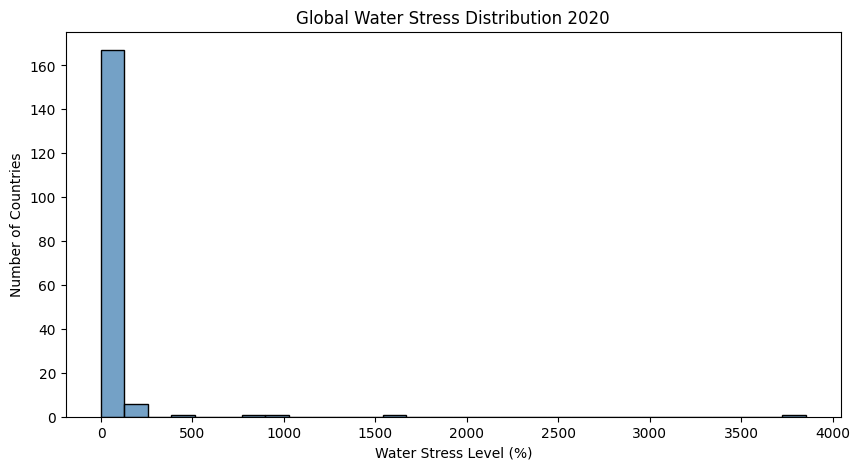

In [178]:
plt.figure(figsize=(10,5))
sns.histplot(df_wb_2020['Water_Stress_2020'], bins=30, color='steelblue')
plt.title("Global Water Stress Distribution 2020")
plt.xlabel("Water Stress Level (%)")
plt.ylabel("Number of Countries")
plt.show()

# our model is designed to detect whether water is safe to consume in these high stress regions on the right

In [179]:
# Evaluating after the merge

from sklearn.metrics import accuracy_score, classification_report


print("merged set")

# Features and target
X_merged = df_merged.drop(columns=['Potability', 'Country', 'Code'])
y_merged = df_merged['Potability']

# 80% train, 20% test
X_train_merged, X_test_merged, y_train_merged, y_test_merged = train_test_split(
    X_merged, y_merged, test_size=0.2, random_state=42
)

# Scaling features
scaler_merged = StandardScaler()
X_train_scaled_merged = scaler_merged.fit_transform(X_train_merged)
X_test_scaled_merged = scaler_merged.transform(X_test_merged)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}


for name, model in models.items():
    model.fit(X_train_scaled_merged, y_train_merged)
    preds = model.predict(X_test_scaled_merged)
    acc = accuracy_score(y_test_merged, preds)
    print(f"{name} Accuracy (After Merge): {acc:.4f}")

merged set
Logistic Regression Accuracy (After Merge): 0.5167
Random Forest Accuracy (After Merge): 0.8167
Decision Tree Accuracy (After Merge): 0.7479
K-Nearest Neighbors Accuracy (After Merge): 0.7000


In [180]:
for name, model in [("Random Forest", rf), ("Logistic Regression", lr)]:
    y_pred = model.predict(X_test_scaled)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred,
          target_names=["Not Potable", "Potable"]))


Random Forest
              precision    recall  f1-score   support

 Not Potable       0.69      0.90      0.78       412
     Potable       0.66      0.32      0.43       244

    accuracy                           0.68       656
   macro avg       0.67      0.61      0.60       656
weighted avg       0.68      0.68      0.65       656


Logistic Regression
              precision    recall  f1-score   support

 Not Potable       0.63      1.00      0.77       412
     Potable       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


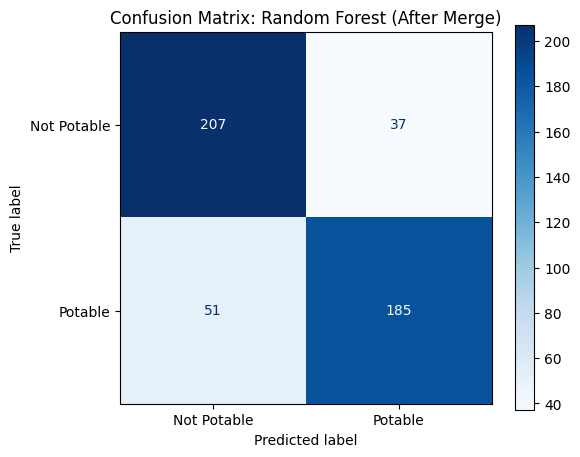

In [181]:
# Confusion Matrix

# We pick the best model
best_model = models["Random Forest"]
rf_preds_merged = best_model.predict(X_test_scaled_merged)

cm = confusion_matrix(y_test_merged, rf_preds_merged)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Potable", "Potable"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Random Forest (After Merge)")
plt.show()

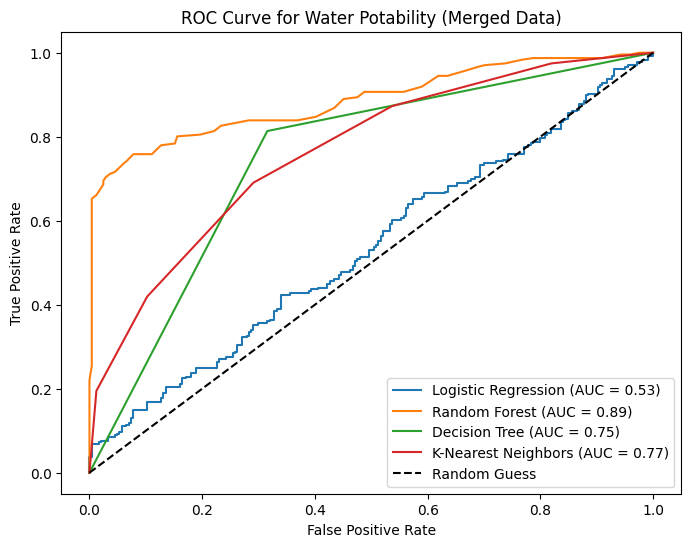

In [182]:
# ROC CURVE

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    # Predicting probabilities
    probs = model.predict_proba(X_test_scaled_merged)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_merged, probs)
    roc_auc = auc(fpr, tpr)

    # Plotting the lines
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plotting the random guess baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve for Water Potability (Merged Data)')
ax.legend(loc="lower right")

plt.show()